# 1. Objectif

Ce notebook a pour objectif d’analyser les données consolidées du cabinet médical afin d’identifier les principales tendances d’activité, de recettes et d’organisation du cabinet sur la période étudiée.

L’analyse vise à fournir une vision structurée de l’évolution du cabinet, à mettre en évidence certains indicateurs clés et à proposer des pistes d’optimisation opérationnelle.

# 2. Chargement et préparation des données

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Chargement
df = pd.read_csv(
    "cabinet_medical_clean.csv",
    parse_dates=['date']
)

# 3. Analyse de l’activité du cabinet

In [3]:
bilan_global = df[['consultations', 'visites', 'recette']].sum().round(2)
bilan_global

consultations      9892.00
visites              43.00
recette          272018.31
dtype: float64

In [4]:
# Estimation du nombre de patients distincts sur l'ensemble de la période
df['patient_id'].nunique()

987

Le nombre de patients distincts présenté ici constitue une approximation.

L’identifiant patient ayant été construit à partir du seul nom de famille renseigné dans les exports sources, plusieurs individus partageant le même nom (homonymes ou membres d’un même foyer) peuvent être comptabilisés comme un seul patient.

Cet indicateur doit donc être interprété comme une estimation basse du nombre réel de patients distincts.

## Fonctions utilitaires

In [5]:
noms_mois = {
    1: 'Janvier',
    2: 'Février',
    3: 'Mars',
    4: 'Avril',
    5: 'Mai',
    6: 'Juin',
    7: 'Juillet',
    8: 'Août',
    9: 'Septembre',
    10: 'Octobre',
    11: 'Novembre',
    12: 'Décembre'
}

def activite_mensuelle(df_annee):
    df_temp = df_annee.copy()

    activite = (
        df_temp.groupby(df_temp['date'].dt.month)[
            ['consultations', 'visites', 'recette']
        ]
        .sum()
        .reset_index()
    )

    activite = activite.rename(columns={'date': 'mois'})
    activite['mois'] = activite['mois'].map(noms_mois)

    return activite.round(2)

In [6]:
def plot_activite_recettes(activite_mensuelle, annee):
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace(
        go.Bar(
            x=activite_mensuelle['mois'],
            y=activite_mensuelle['consultations'],
            name='Consultations'
        ),
        secondary_y=False
    )

    fig.add_trace(
        go.Scatter(
            x=activite_mensuelle['mois'],
            y=activite_mensuelle['recette'],
            name='Recettes',
            mode='lines+markers'
        ),
        secondary_y=True
    )

    fig.update_layout(
        title=f"Activité et recettes mensuelles du cabinet en {annee}",
        xaxis_title="Mois",
        legend_title="Indicateurs"
    )

    fig.update_yaxes(
        title_text="Nombre de consultations",
        secondary_y=False
    )

    fig.update_yaxes(
        title_text="Recettes (€)",
        secondary_y=True
    )

    fig.show()

In [7]:
def activite_hebdomadaire(df_annee):
    df_temp = df_annee.copy()

    df_temp['semaine'] = df_temp['date'].dt.isocalendar().week

    activite_hebdo = (
        df_temp.groupby('semaine')[
            ['consultations', 'visites', 'recette']
        ]
        .sum()
        .reset_index()
    )

    return activite_hebdo.round(2)

In [8]:
ordre_jours = [
    'Lundi',
    'Mardi',
    'Mercredi',
    'Jeudi',
    'Vendredi',
    'Samedi',
    'Dimanche'
]

def activite_par_jour_semaine(df_annee):
    df_temp = df_annee.copy()

    activite_journaliere = (
        df_temp.groupby('date')[['consultations', 'recette']]
        .sum()
        .reset_index()
    )

    activite_journaliere['jour_semaine'] = (
        activite_journaliere['date']
        .dt.day_name(locale='fr_FR')
    )

    activite_jour = (
        activite_journaliere.groupby('jour_semaine')[
            ['consultations', 'recette']
        ]
        .mean()
        .reset_index()
    )

    activite_jour['jour_semaine'] = pd.Categorical(
        activite_jour['jour_semaine'],
        categories=ordre_jours,
        ordered=True
    )

    activite_jour = activite_jour.sort_values('jour_semaine')

    return activite_jour.round(2)

## 3.1 Analyse de l’activité et des recettes — 2022

In [9]:
# Extraction des données 2022
df_2022 = df[df['date'].dt.year == 2022].copy()

In [10]:
# Estimation du nombre de patients distincts
df_2022['patient_id'].nunique()

546

In [11]:
# Activité et recettes sur l'année 2022
df_2022[['consultations', 'visites', 'recette']].sum().round(2)

consultations     2344.0
visites             21.0
recette          62072.5
dtype: float64

In [12]:
# Activité mensuelle 2022
activite_mensuelle_2022 = activite_mensuelle(df_2022)
activite_mensuelle_2022

,mois,consultations,visites,recette
0,Janvier,239.0,0.0,6536.5
1,Février,204.0,1.0,5459.0
2,Mars,178.0,0.0,4775.0
3,Avril,192.0,1.0,4792.0
4,Mai,202.0,0.0,5248.0
5,Juin,178.0,0.0,4685.0
6,Juillet,196.0,2.0,5120.0
7,Août,50.0,0.0,1321.0
8,Septembre,258.0,1.0,6723.5
9,Octobre,241.0,0.0,6283.0


**Anomalie identifiée :**  
Les semaines 50 et 51 de l’année 2022 présentent un volume inhabituellement élevé de visites.

L’inspection des fichiers sources suggère une probable erreur de saisie, certaines lignes de la seconde partie des tableaux semblant avoir été renseignées comme des visites de manière incorrecte.

Cette anomalie n’altère pas les grandes tendances observées mais devra être corrigée lors d’une éventuelle mise à jour des données sources afin de préserver la traçabilité des modifications.

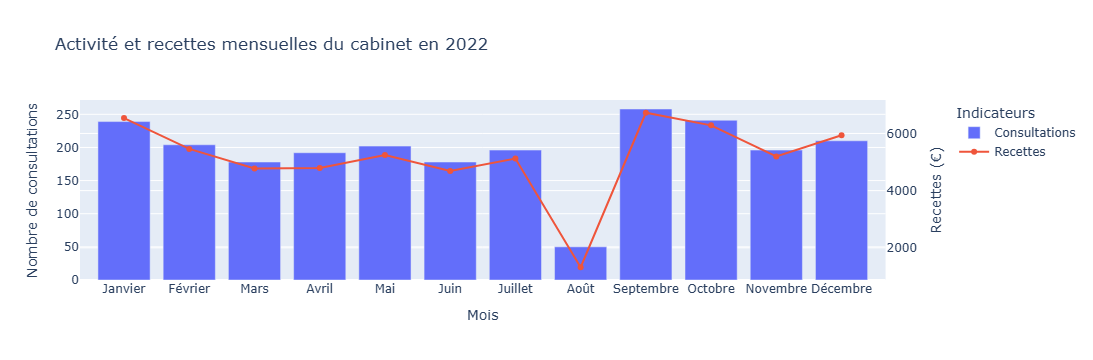

In [13]:
# Visualisation mensuelle activité / recettes
plot_activite_recettes(activite_mensuelle_2022, 2022)

### Premières observations sur l'activité en 2022

L’activité du cabinet apparaît globalement stable sur l’année, avec un volume mensuel de consultations généralement compris entre 180 et 240 actes.

Une baisse marquée est observée au mois d’août, vraisemblablement liée à une période de congés ou à une réduction d’activité estivale.

À l’inverse, un regain d’activité est visible à la rentrée, avec un pic en septembre et un niveau soutenu en octobre. Cette dynamique peut s’expliquer par la reprise post-estivale, les renouvellements d’ordonnances ou encore certaines pathologies saisonnières de début d’automne et d’hiver.

Quelques anomalies de saisie ont également été identifiées dans les données sources, sans impact majeur sur les grandes tendances observées.

In [14]:
activite_hebdo_2022 = activite_hebdomadaire(df_2022)

### Analyse de l’activité et des recettes par jour de la semaine

In [15]:
# Activité moyenne par jour de la semaine
activite_jour_2022 = activite_par_jour_semaine(df_2022)
activite_jour_2022

,jour_semaine,consultations,recette
1,Lundi,9.88,264.14
2,Mardi,9.93,253.96
3,Mercredi,9.36,247.43
0,Jeudi,9.22,240.79
5,Vendredi,11.21,301.88
4,Samedi,7.39,201.47


### Activité moyenne par jour de la semaine en 2022

L’analyse journalière montre une activité relativement homogène en semaine, avec environ 9 à 10 consultations par jour du lundi au jeudi.

Le vendredi apparaît comme le jour le plus chargé, avec en moyenne plus de 11 consultations et les recettes journalières moyennes les plus élevées.

Le samedi présente une activité plus réduite, avec environ 7 consultations en moyenne et un niveau de recettes logiquement inférieur.

Globalement, la structure hebdomadaire de l’activité semble cohérente, avec une intensification en fin de semaine.

## 3.2 Analyse de l’activité et des recettes — 2023

In [16]:
# Extraction des données 2023
df_2023 = df[df['date'].dt.year == 2023].copy()

In [17]:
# Estimation du nombre de patients distincts
df_2023['patient_id'].nunique()

525

In [18]:
# Activité et recettes sur l'année 2023
df_2023[['consultations', 'visites','recette']].sum()

consultations     2386.0
visites              6.0
recette          61779.7
dtype: float64

In [19]:
# Activité mensuelle 2023
activite_mensuelle_2023 = activite_mensuelle(df_2023)
activite_mensuelle_2023

,mois,consultations,visites,recette
0,Janvier,198.0,1.0,5076.00
1,Février,268.0,0.0,6652.00
2,Mars,232.0,1.0,5992.50
3,Avril,200.0,0.0,5045.50
4,Mai,192.0,0.0,4997.50
5,Juin,235.0,0.0,6092.50
6,Juillet,203.0,2.0,5332.00
7,Août,34.0,0.0,856.00
8,Septembre,224.0,0.0,5814.50
9,Octobre,235.0,0.0,6026.00


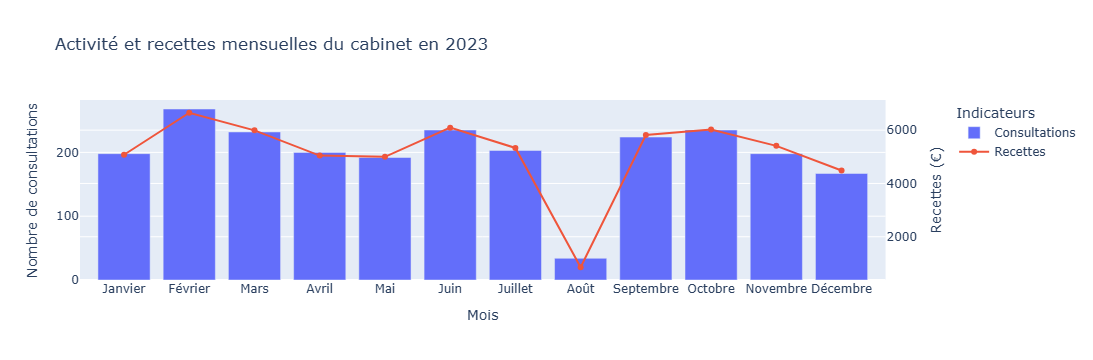

In [20]:
# Visualisation mensuelle activité / recettes
plot_activite_recettes(activite_mensuelle_2023, 2023)

### Premières observations sur l'activité en 2023

L’activité du cabinet en 2023 apparaît particulièrement stable, avec un volume mensuel de consultations généralement compris entre 190 et 235 actes.

Le mois de février constitue le pic annuel, tant en volume d’activité qu’en recettes, ce qui peut refléter une pression saisonnière plus forte en période hivernale.

Comme en 2022, le mois d’août se distingue par une baisse très marquée de l’activité, vraisemblablement liée à une période de congés ou à une réduction d’activité estivale.

Les mois de septembre et octobre confirment une reprise soutenue à la rentrée, bien que moins accentuée que l’année précédente.

Globalement, l’activité du cabinet présente une forte régularité sur l’ensemble de l’année.

In [21]:
activite_hebdo_2023 = activite_hebdomadaire(df_2023)

### Analyse de l'activité et des recettes par jour de semaine

In [22]:
# Activité moyenne par jour de la semaine
activite_jour_2023 = activite_par_jour_semaine(df_2023)
activite_jour_2023

,jour_semaine,consultations,recette
2,Lundi,9.84,249.80
3,Mardi,10.55,268.84
4,Mercredi,10.55,277.86
1,Jeudi,9.16,236.99
6,Vendredi,9.86,255.70
5,Samedi,5.49,147.33
0,Dimanche,3.00,90.00


### Activité moyenne par jour de la semaine en 2023

L’analyse journalière met en évidence une activité soutenue et relativement homogène du lundi au vendredi, avec environ 9 à 10 consultations par jour.

Les mardis et mercredis apparaissent comme les journées les plus actives, avec plus de 10 consultations en moyenne ainsi que les recettes journalières moyennes les plus élevées.

Le jeudi présente une activité légèrement plus modérée, tandis que le samedi marque une baisse nette, avec un volume moyen d’environ 5 consultations.

Une activité très marginale est observée le dimanche, correspondant à des cas exceptionnels.

## 3.3 Analyse de l’activité et des recettes — 2024

In [23]:
# Extraction des données 2024
df_2024 = df[df['date'].dt.year == 2024].copy()

In [24]:
# Estimation du nombre de patients distincts
df_2024['patient_id'].nunique()

546

In [25]:
# Activité et recettes sur l'année 2024
df_2024[['consultations', 'visites','recette']].sum()

consultations     2347.0000
visites              7.0000
recette          63002.6128
dtype: float64

In [26]:
# Activité mensuelle 2024
activite_mensuelle_2024 = activite_mensuelle(df_2024)
activite_mensuelle_2024

,mois,consultations,visites,recette
0,Janvier,226.0,1.0,5979.55
1,Février,218.0,0.0,5796.56
2,Mars,228.0,1.0,6181.25
3,Avril,207.0,0.0,5537.90
4,Mai,190.0,1.0,5070.20
5,Juin,205.0,0.0,5516.55
6,Juillet,207.0,2.0,5552.45
7,Août,53.0,0.0,1418.55
8,Septembre,234.0,0.0,6273.15
9,Octobre,257.0,0.0,6768.20


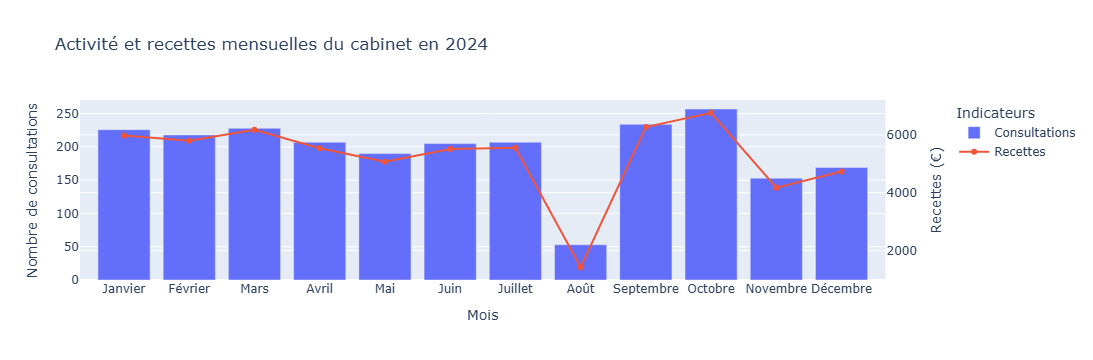

In [27]:
# Visualisation mensuelle activité / recettes
plot_activite_recettes(activite_mensuelle_2024, 2024)

### Premières observations sur l'activité en 2024

L’activité du cabinet en 2024 demeure globalement très stable, dans la continuité des années précédentes, avec un volume mensuel de consultations généralement compris entre 190 et 230 actes.

Le second semestre apparaît particulièrement dynamique, avec un pic d’activité observé en octobre, qui constitue également le mois le plus rentable de l’année.

Comme les années précédentes, le mois d’août se distingue par une baisse très marquée de l’activité, confirmant un schéma saisonnier récurrent probablement lié à la période estivale.

Les mois de novembre et décembre montrent un ralentissement relatif après la forte activité de la rentrée.

Dans l’ensemble, le cabinet conserve un rythme d’activité remarquablement régulier.

In [28]:
activite_hebdo_2024 = activite_hebdomadaire(df_2024)

### Analyse de l'activité et des recettes par jour de semaine

In [29]:
# Activité moyenne par jour de la semaine
activite_jour_2024 = activite_par_jour_semaine(df_2024)
activite_jour_2024

,jour_semaine,consultations,recette
2,Lundi,10.34,275.36
3,Mardi,9.41,251.83
4,Mercredi,8.65,236.06
1,Jeudi,8.93,236.24
6,Vendredi,9.72,263.71
5,Samedi,5.22,139.25
0,Dimanche,8.00,240.00


### Activité moyenne par jour de la semaine en 2024

L’activité hebdomadaire en 2024 reste structurée autour d’une forte activité du lundi au vendredi.

Le lundi apparaît comme la journée la plus chargée, avec plus de 10 consultations en moyenne, suivi du vendredi et du mardi.

Les mercredis et jeudis présentent un niveau d’activité légèrement plus modéré, tandis que le samedi conserve un volume d’activité réduit, conforme aux années précédentes.

Quelques occurrences exceptionnelles d’activité le dimanche sont observées, sans caractère structurel.

Globalement, l’organisation hebdomadaire du cabinet demeure stable et cohérente.

## 3.4 Analyse de l’activité et des recettes — 2025

In [30]:
# Extraction des données 2025
df_2025 = df[df['date'].dt.year == 2025].copy()

In [31]:
# Estimation du nombre de patients distincts
df_2025['patient_id'].nunique()

487

In [32]:
# Activité et recettes sur l'année 2025
df_2025[['consultations', 'visites','recette']].sum()

consultations     2126.0
visites              5.0
recette          64514.5
dtype: float64

In [33]:
# Activité mensuelle 2025
activite_mensuelle_2025 = activite_mensuelle(df_2025)
activite_mensuelle_2025

,mois,consultations,visites,recette
0,Janvier,204.0,1.0,6194.0
1,Février,185.0,0.0,5542.0
2,Mars,221.0,1.0,6743.0
3,Avril,183.0,0.0,5477.0
4,Mai,171.0,1.0,5187.0
5,Juin,134.0,0.0,4115.0
6,Juillet,225.0,1.0,6926.0
7,Août,37.0,0.0,1115.0
8,Septembre,220.0,1.0,6663.0
9,Octobre,218.0,0.0,6496.0


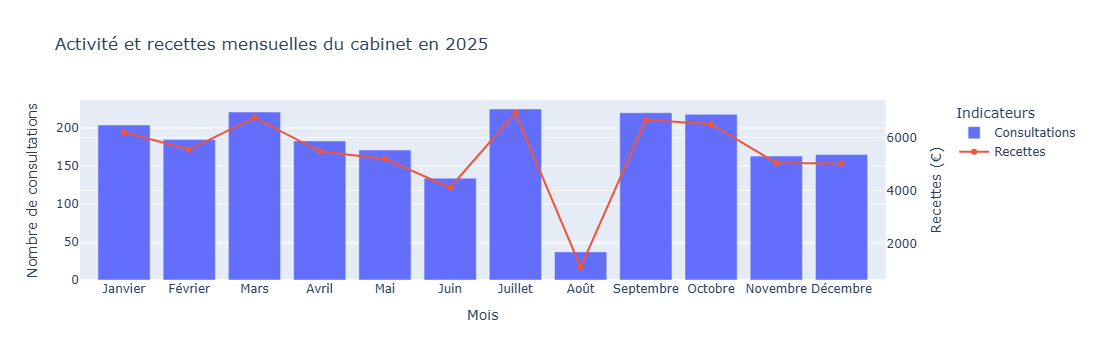

In [34]:
# Visualisation mensuelle activité / recettes
plot_activite_recettes(activite_mensuelle_2025, 2025)

### Premières observations sur l'activité en 2025

L’activité du cabinet en 2025 apparaît légèrement moins soutenue que les années précédentes, avec un volume de consultations globalement en retrait.

Cette baisse n’est toutefois pas uniforme : plusieurs mois conservent un niveau d’activité élevé, notamment mars, juillet, septembre et octobre.

Le mois de juin marque un ralentissement notable, tandis que le mois d’août confirme une nouvelle fois son statut de période creuse récurrente.

Malgré une activité légèrement inférieure en volume, le niveau de recettes demeure élevé, suggérant une stabilité économique du cabinet.

L’ensemble reste cohérent avec la saisonnalité observée les années précédentes.

In [35]:
activite_hebdo_2025 = activite_hebdomadaire(df_2025)

### Analyse de l'activité et des recettes par jour de semaine

In [36]:
# Activité moyenne par jour de la semaine
activite_jour_2025 = activite_par_jour_semaine(df_2025)
activite_jour_2025

,jour_semaine,consultations,recette
1,Lundi,9.35,276.95
2,Mardi,8.75,265.74
3,Mercredi,8.40,259.78
0,Jeudi,8.36,253.63
5,Vendredi,9.51,288.65
4,Samedi,6.08,186.04


### Activité moyenne par jour de la semaine en 2025

L’activité hebdomadaire en 2025 reste globalement bien structurée, avec une activité soutenue du lundi au vendredi.

Le vendredi constitue la journée moyenne la plus chargée et la plus rentable, suivi de près par le lundi.

Les journées du mardi au jeudi présentent un niveau d’activité relativement homogène, légèrement inférieur aux journées de début et de fin de semaine.

Le samedi conserve un niveau d’activité plus réduit, tout en restant plus actif que lors de certaines années précédentes.

La structure hebdomadaire du cabinet apparaît ainsi globalement stable, malgré un léger recul du volume global annuel.

## 3.5 Analyse de l’activité et des recettes — 2026 (données partielles)

In [37]:
# Extraction des données 2026
df_2026 = df[df['date'].dt.year == 2026].copy()

In [38]:
# Estimation du nombre de patients distincts sur la période
df_2026['patient_id'].nunique()

312

In [39]:
# Activité et recettes sur la période
df_2026[['consultations', 'visites','recette']].sum()

consultations      689.0
visites              4.0
recette          20649.0
dtype: float64

In [40]:
# Activité mensuelle 2026
activite_mensuelle_2026 = activite_mensuelle(df_2026)
activite_mensuelle_2026

,mois,consultations,visites,recette
0,Janvier,175.0,0.0,5293.0
1,Février,92.0,1.0,2805.0
2,Mars,185.0,0.0,5506.0
3,Avril,176.0,2.0,5235.0
4,Mai,61.0,1.0,1810.0


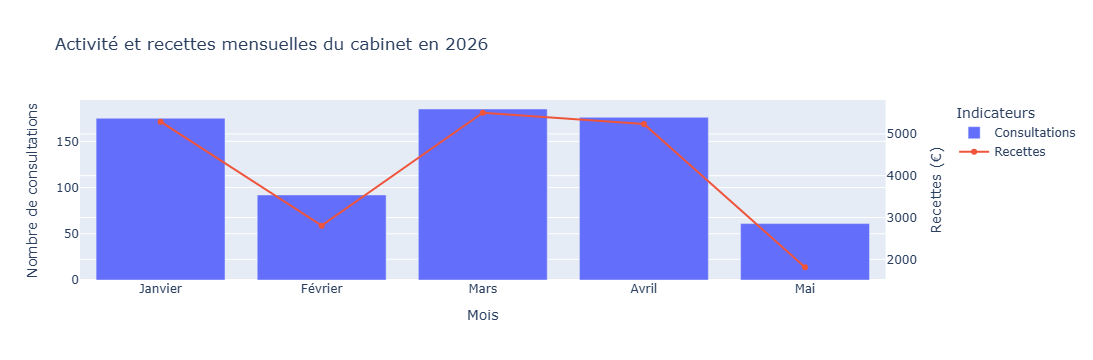

In [41]:
# Visualisation mensuelle activité / recettes
plot_activite_recettes(activite_mensuelle_2026, 2026)

### Premières observations sur l'activité en 2026 (données partielles)

Les données disponibles pour 2026 couvrent uniquement la période du 1er janvier au 16 mai ; toute comparaison directe avec les années complètes précédentes doit donc être interprétée avec prudence.

Sur la période observée, l’activité du cabinet apparaît soutenue, avec des niveaux de consultations élevés en janvier, mars et avril.

Le mois de février présente un volume plus modéré, tandis que le mois de mai n’étant que partiellement couvert, il ne peut être analysé comme un mois complet.

À ce stade, les premiers mois de 2026 semblent globalement cohérents avec le rythme d’activité observé les années précédentes.

In [42]:
activite_hebdo_2026 = activite_hebdomadaire(df_2026)

### Analyse de l'activité et des recettes par jour de semaine

In [43]:
# Activité moyenne par jour de la semaine
activite_jour_2026 = activite_par_jour_semaine(df_2026)
activite_jour_2026

,jour_semaine,consultations,recette
1,Lundi,7.33,221.17
2,Mardi,9.38,278.12
3,Mercredi,8.36,254.50
0,Jeudi,8.31,247.31
5,Vendredi,7.50,218.17
4,Samedi,5.58,173.33


### Activité moyenne par jour de la semaine en 2026 (données partielles)

Sur la période observée, l’activité hebdomadaire conserve une structure cohérente avec les années précédentes.

Le mardi apparaît comme la journée moyenne la plus active et la plus rentable, avec plus de 9 consultations en moyenne.

Les mercredis et jeudis présentent également un niveau d’activité soutenu, tandis que les lundis et vendredis apparaissent légèrement en retrait sur cette période.

Le samedi conserve un volume d’activité plus faible, conformément à la structure observée les années précédentes.

Ces observations restent toutefois à interpréter avec prudence compte tenu du caractère partiel des données 2026.

## 3.6 Analyse comparative interannuelle

### Dynamique de la patientèle

In [44]:
def comparer_patientele(df_annee_n, df_annee_n1, annee_n, annee_n1):
    patients_n = set(df_annee_n['patient_id'])
    patients_n1 = set(df_annee_n1['patient_id'])

    nouveaux = len(patients_n1 - patients_n)
    non_revenus = len(patients_n - patients_n1)
    communs = len(patients_n & patients_n1)

    return {
        'transition': f'{annee_n} → {annee_n1}',
        'nouveaux_patients': nouveaux,
        'patients_non_revenus': non_revenus,
        'patients_communs': communs
    }

In [45]:
comparaisons_patientele = pd.DataFrame([
    comparer_patientele(df_2022, df_2023, 2022, 2023),
    comparer_patientele(df_2023, df_2024, 2023, 2024),
    comparer_patientele(df_2024, df_2025, 2024, 2025),
    comparer_patientele(df_2025, df_2026, 2025, 2026)
])

comparaisons_patientele

,transition,nouveaux_patients,patients_non_revenus,patients_communs
0,2022 → 2023,158,179,367
1,2023 → 2024,181,160,365
2,2024 → 2025,131,190,356
3,2025 → 2026,41,216,271


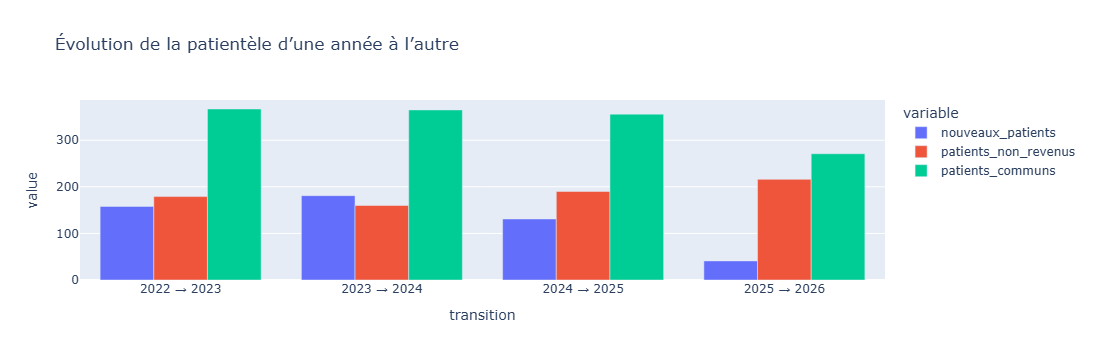

In [46]:
px.bar(
    comparaisons_patientele,
    x='transition',
    y=[
        'nouveaux_patients',
        'patients_non_revenus',
        'patients_communs'
    ],
    barmode='group',
    title='Évolution de la patientèle d’une année à l’autre'
)

### Évolution de la patientèle

L’analyse comparative met en évidence une patientèle globalement stable, structurée autour d’un noyau récurrent d’environ 350 patients présents d’une année sur l’autre.

Chaque année, le cabinet enregistre également un renouvellement non négligeable de patients, avec environ 130 à 180 nouveaux patients estimés selon les périodes observées.

La dynamique observée entre 2022 et 2025 suggère ainsi un équilibre entre fidélisation d’une patientèle régulière et arrivée de nouveaux patients.

Les données 2026 doivent être interprétées avec prudence, l’année n’étant couverte que partiellement, ce qui réduit mécaniquement le nombre de patients observés comme "revenus".

### Estimation du tarif moyen par consultation

In [47]:
tarif_moyen = pd.DataFrame({
    'annee': [2022, 2023, 2024, 2025, 2026],
    'consultations': [
        df_2022['consultations'].sum(),
        df_2023['consultations'].sum(),
        df_2024['consultations'].sum(),
        df_2025['consultations'].sum(),
        df_2026['consultations'].sum()
    ],
    'recette': [
        df_2022['recette'].sum(),
        df_2023['recette'].sum(),
        df_2024['recette'].sum(),
        df_2025['recette'].sum(),
        df_2026['recette'].sum()
    ]
})

tarif_moyen['tarif_moyen_consultation'] = (
    tarif_moyen['recette'] / tarif_moyen['consultations']
)

tarif_moyen

,annee,consultations,recette,tarif_moyen_consultation
0,2022,2344.0,62072.5000,26.481442
1,2023,2386.0,61779.7000,25.892582
2,2024,2347.0,63002.6128,26.843891
3,2025,2126.0,64514.5000,30.345484
4,2026,689.0,20649.0000,29.969521


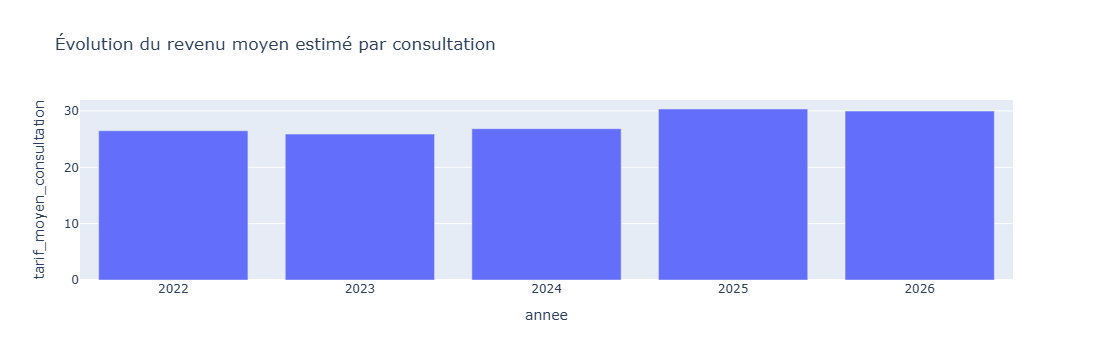

In [48]:
px.bar(
    tarif_moyen,
    x='annee',
    y='tarif_moyen_consultation',
    title='Évolution du revenu moyen estimé par consultation'
)

### Estimation du tarif moyen par consultation

L’estimation du revenu moyen par consultation apparaît remarquablement stable entre 2022 et 2024, autour de 26 € par acte.

Une rupture nette est observée à partir de 2025, avec un revenu moyen estimé proche de 30 € par consultation, tendance qui semble se prolonger sur les premiers mois de 2026.

Cette évolution permet d’expliquer le maintien, voire la progression des recettes du cabinet malgré un léger recul du volume de consultations observé en 2025.

Cette hausse peut refléter une évolution tarifaire ou une modification de la structure des actes facturés.
    

# 4. Analyse de la charge de travail et pistes d’optimisation

Dans cette section, nous cherchons à estimer indirectement la charge de travail du cabinet à partir du volume de consultations observé.

D’après les horaires d’ouverture communiqués (9h00–12h00 puis 14h00–19h00), l’amplitude théorique quotidienne de consultation est estimée à 8 heures, soit 480 minutes par jour.

Cette estimation constitue une borne haute, dans la mesure où elle ne prend pas en compte le temps consacré aux tâches administratives, aux appels téléphoniques, aux urgences éventuelles ou aux interruptions d’activité.

L’objectif n’est donc pas de mesurer la durée réelle des consultations, mais d’obtenir un ordre de grandeur permettant d’évaluer la charge de travail du cabinet et d’identifier d’éventuelles pistes d’optimisation.

In [49]:
bilan_charge = pd.DataFrame({
    'annee': [2022, 2023, 2024, 2025, 2026],
    'consultations': [
        df_2022['consultations'].sum(),
        df_2023['consultations'].sum(),
        df_2024['consultations'].sum(),
        df_2025['consultations'].sum(),
        df_2026['consultations'].sum()
    ],
    'jours_travailles': [
        df_2022['date'].nunique(),
        df_2023['date'].nunique(),
        df_2024['date'].nunique(),
        df_2025['date'].nunique(),
        df_2026['date'].nunique()
    ]
})

bilan_charge['consultations_par_jour'] = (
    bilan_charge['consultations'] / bilan_charge['jours_travailles']
)

bilan_charge['duree_moyenne_estimee_min'] = (
    480 / bilan_charge['consultations_par_jour']
)

bilan_charge

,annee,consultations,jours_travailles,consultations_par_jour,duree_moyenne_estimee_min
0,2022,2344.0,246,9.528455,50.375427
1,2023,2386.0,255,9.356863,51.299246
2,2024,2347.0,268,8.757463,54.810396
3,2025,2126.0,252,8.436508,56.895579
4,2026,689.0,88,7.829545,61.306241


### Estimation indirecte de la charge de travail

L’estimation indirecte de la charge de travail suggère un temps moyen théorique par consultation compris entre 50 et 57 minutes sur les années complètes analysées.

Cette durée apparaît supérieure aux standards habituellement observés en médecine générale, mais peut s’expliquer par plusieurs facteurs : temps administratif, interruptions d’activité, gestion des imprévus ou encore nature des consultations réalisées.

Le profil d’exercice du cabinet, incluant notamment une activité d’homéopathie, peut également contribuer à des consultations plus longues que la moyenne.

Une tendance à l’allongement progressif de cette durée implicite semble apparaître entre 2022 et 2025, ce qui peut traduire soit une évolution de l’organisation quotidienne, soit une prise en charge plus approfondie des patients.

### Mise en perspective avec les standards observés

À titre indicatif, les données publiées par la DREES situent historiquement la durée moyenne d’une consultation de médecine générale autour de 15 à 20 minutes.

L’estimation indirecte obtenue ici se situe au-dessus de cet ordre de grandeur.

Cette différence ne traduit pas nécessairement une inefficacité organisationnelle : elle peut refléter le temps consacré aux tâches administratives, la gestion d’imprévus, la nature des consultations ou encore les spécificités du cabinet, notamment un accompagnement plus individualisé des patients.

Elle invite néanmoins à une réflexion sur l’organisation du temps médical, afin d’identifier d’éventuels leviers d’optimisation compatibles avec le mode d’exercice du cabinet.

### Recommandations opérationnelles

#### Optimisation progressive du temps médical

L’analyse suggère une durée moyenne implicite de prise en charge supérieure aux standards habituellement observés en médecine générale.

Cette spécificité peut refléter une réelle qualité d’écoute et un accompagnement individualisé apprécié des patients, constituant une véritable force du cabinet.

Dans une logique de préservation de la charge de travail et de maintien durable de l’activité, une optimisation progressive de certaines consultations pourrait néanmoins être envisagée.

À titre illustratif, une réduction moyenne de 10 minutes par consultation sur une journée type d’environ 9 consultations représenterait un gain potentiel proche de 1h30 par jour.

Ce temps libéré pourrait être réinvesti utilement dans des tâches à forte valeur ajoutée souvent reléguées au second plan : meilleure structuration de la saisie quotidienne des données, traitement administratif, gestion des imprévus ou simplement allègement de la charge de travail.

L’objectif n’est pas d’augmenter mécaniquement le volume de patients pris en charge, mais d’améliorer l’organisation globale du cabinet tout en préservant la qualité du suivi et le confort d’exercice.